<a href="https://colab.research.google.com/github/shauryasachdev/Vizuara_CV/blob/main/MaskR_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Import Necessary Libraries

import os
import torch
import torchvision
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import time
from pathlib import Path
from PIL import Image
from typing import Tuple, Dict, List
import albumentations as A

# Import specific torchvision components
import torchvision.transforms.v2 as T   # ← v2 !
from torchvision.tv_tensors import Image as tv_tensors_Image, Mask as tv_tensors_Mask, BoundingBoxes as tv_tensors_BoundingBoxes
from torchvision.io import read_image
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import masks_to_boxes

# Set the device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Devid:", device)
print("Torch", torch.__version__, "Torchvision:", torchvision.__version__)

Devid: cuda
Torch 2.10.0+cu128 Torchvision: 0.25.0+cu128


In [34]:
# Penn-Fudan Ped = pdestricans with per-instance masks
# https://www.cis.upenn.edu/~jshi/ped_html-

# Create a new directory if it does not exist
from pathlib import Path
import os

data_root = Path("data")
data_root.mkdir(parents=True, exist_ok=True)

dataset_dir = data_root / "PennFudanPed"
zip_path = data_root / "PennFudanPed.zip"

# Clean any previous incomplete extraction
if dataset_dir.exists():
    print("Removing any old/incomplete PennFudanPed folder...")
    !rm -rf {dataset_dir}

print("Downloading PennFudanPed.zip...")
!wget -q https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -O {zip_path}

print("Extracting with overwrite...")
!unzip -q -o {zip_path} -d {data_root}

# Quick verification
print("\nExtraction complete. Listing contents:")
!ls -l {dataset_dir}
!echo "\nPNGImages preview:"
!ls {dataset_dir}/PNGImages | head -n 6
!echo "\nPedMasks preview:"
!ls {dataset_dir}/PedMasks | head -n 6

Removing any old/incomplete PennFudanPed folder...
Extracting with overwrite...

Extraction complete. Listing contents:
total 44
-rw------- 1 root root  1627 Sep 17  2007 added-object-list.txt
drwx------ 2 root root 12288 Oct 28  2007 Annotation
drwx------ 2 root root 12288 Oct 28  2007 PedMasks
drwx------ 2 root root 12288 Oct 28  2007 PNGImages
-rw------- 1 root root  2416 Oct 28  2007 readme.txt
\nPNGImages preview:
FudanPed00001.png
FudanPed00002.png
FudanPed00003.png
FudanPed00004.png
FudanPed00005.png
FudanPed00006.png
\nPedMasks preview:
FudanPed00001_mask.png
FudanPed00002_mask.png
FudanPed00003_mask.png
FudanPed00004_mask.png
FudanPed00005_mask.png
FudanPed00006_mask.png


In [35]:
from pathlib import Path

data_root = Path("data")
dataset_path = data_root / "PennFudanPed"

print("Full dataset path:", dataset_path.absolute())
print("Dataset folder exists?", dataset_path.exists())

if dataset_path.exists():
    print("\nSubfolders:")
    print("PNGImages exists?", (dataset_path / "PNGImages").exists())
    print("PedMasks exists?", (dataset_path / "PedMasks").exists())

    if (dataset_path / "PNGImages").exists():
        imgs = sorted((dataset_path / "PNGImages").glob("*.png"))
        print(f"Number of images found: {len(imgs)}")
        if imgs:
            print("Example image:", imgs[0].name)
        else:
            print("→ No .png files in PNGImages!")

    if (dataset_path / "PedMasks").exists():
        masks = sorted((dataset_path / "PedMasks").glob("*.png"))
        print(f"Number of masks found: {len(masks)}")
else:
    print("→ Dataset folder does NOT exist!")

Full dataset path: /content/data/PennFudanPed
Dataset folder exists? True

Subfolders:
PNGImages exists? True
PedMasks exists? True
Number of images found: 170
Example image: FudanPed00001.png
Number of masks found: 170


In [36]:
dataset = PennFudanDataset(dataset_dir, get_transform(train=True))
print("Dataset size (total images):", len(dataset))  # Should be 170

Dataset size (total images): 170


In [38]:
# 2. Dataset Class (fixed & completed)
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root: Path, transforms=None):
        self.root = root
        self.transforms = transforms
        # All images & masks files, sorted
        self.imgs = sorted((root / "PNGImages").glob("*.png"))
        self.masks = sorted((root / "PedMasks").glob("*.png"))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = self.imgs[idx]
        mask_path = self.masks[idx]

        img = read_image(str(img_path))   # shape: (C, H, W)
        mask = read_image(str(mask_path)) # shape: (1, H, W), instances = different pixel values

        # Extract unique object IDs (skip background=0)
        obj_ids = torch.unique(mask)
        obj_ids = obj_ids[1:]           # remove background
        num_objs = len(obj_ids)

        # Convert to binary masks (one per instance)
        masks = (mask == obj_ids[:, None, None]).to(torch.uint8)

        # Bounding boxes from masks
        boxes = masks_to_boxes(masks)

        # Labels: only 1 class (person), label=1
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Convert to tv_tensors format (recommended in newer torchvision)
        img = tv_tensors_Image(img)

        target = {
            "boxes": tv_tensors_BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape[-2:]),
            "masks": tv_tensors_Mask(masks),
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

In [56]:
# Then your get_transform function becomes:
def get_transform(train: bool):
    transforms = []
    transforms.append(T.ToImage()) # Add this to convert PIL Image to TV_Tensor Image
    if train:
        transforms.append(T.RandomHorizontalFlip(p=0.5))  # p= instead of probability arg
    transforms += [
        T.ToDtype(torch.float32, scale=True),   # Note: torch.float32 (not torch.float)
        # T.ToPureTensor(),                     # Optional now – often not needed in recent v2
    ]
    return T.Compose(transforms)

In [53]:
# 4. Model – replace heads for 2 classes (background + person)
def get_model(num_classes: int = 2):
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Replace box predictor
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # Replace mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model

In [54]:
# 5. Main execution
if __name__ == "__main__":
    dataset = PennFudanDataset(dataset_dir, get_transform(train=True))
    dataset_test = PennFudanDataset(dataset_dir, get_transform(train=False))

    # Small train/val split (tutorial uses last 50 as test)
    indices = torch.randperm(len(dataset)).tolist()
    dataset_train = torch.utils.data.Subset(dataset, indices[:-50])
    dataset_val   = torch.utils.data.Subset(dataset_test, indices[-50:])

    def collate_fn(batch):
        return tuple(zip(*batch))

    data_loader_train = torch.utils.data.DataLoader(
        dataset_train, batch_size=2, shuffle=True,
        num_workers=2, collate_fn=collate_fn
    )

    data_loader_test = torch.utils.data.DataLoader(
        dataset_val, batch_size=1, shuffle=False,
        num_workers=2, collate_fn=collate_fn
    )

    model = get_model(num_classes=2)
    model.to(device)

    # Optimizer & scheduler (simple)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    # Train for a few epochs (increase for better results)
    num_epochs = 10   # change as needed

    print("Starting training...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, targets in data_loader_train:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            running_loss += losses.item()

        lr_scheduler.step()
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss / len(data_loader_train):.4f}")

    print("Training finished.")

    # Save model (optional)
    torch.save(model.state_dict(), "mask_rcnn_pennfudan.pth")

    # Quick inference test on one image
    model.eval()
    with torch.no_grad():
        img, _ = dataset_test[0]   # take first test image
        pred = model([img.to(device)])[0]

    print("Inference example:")
    print("Predicted boxes:", pred["boxes"])
    print("Scores:", pred["scores"])
    print("Labels:", pred["labels"])
    print("Masks shape:", pred["masks"].shape)

Starting training...
Epoch [1/10] Loss: 0.5090
Epoch [2/10] Loss: 0.2635
Epoch [3/10] Loss: 0.2235
Epoch [4/10] Loss: 0.1932
Epoch [5/10] Loss: 0.1825
Epoch [6/10] Loss: 0.1780
Epoch [7/10] Loss: 0.1765
Epoch [8/10] Loss: 0.1743
Epoch [9/10] Loss: 0.1759
Epoch [10/10] Loss: 0.1728
Training finished.
Inference example:
Predicted boxes: tensor([[419.4010, 168.2875, 533.8502, 490.8465],
        [160.5065, 179.1720, 297.5886, 428.3957]], device='cuda:0')
Scores: tensor([0.9981, 0.9980], device='cuda:0')
Labels: tensor([1, 1], device='cuda:0')
Masks shape: torch.Size([2, 1, 536, 559])


In [18]:
!pip install albumentations

/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


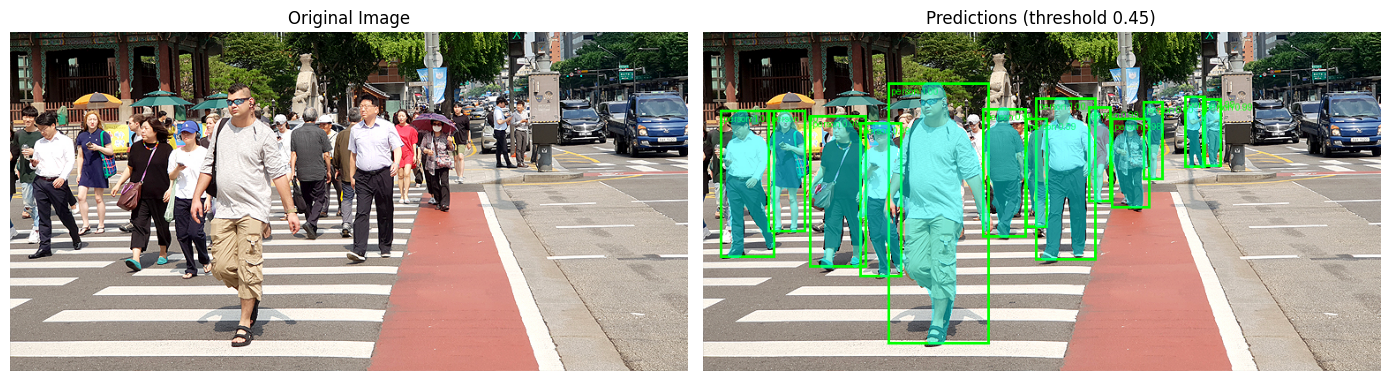

Detected 13 objects with score > 0.45
Scores: ['0.997', '0.996', '0.996', '0.996', '0.994', '0.993', '0.992', '0.992', '0.988', '0.986', '0.983', '0.602', '0.591']


In [60]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as F
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

# ────────────────────────────────────────────────
#  Helper function to visualize predictions on original image
# ────────────────────────────────────────────────
def overlay_predictions_on_image(
    original_image_path: str,
    model,
    device,
    transform,
    score_threshold=0.5,
    mask_threshold=0.5,
    box_color="red",
    mask_color="cyan",
    mask_alpha=0.45,
    figsize=(12, 8)
):
    """
    Loads original image, runs inference, draws boxes + masks on top.

    Args:
        original_image_path (str): path to your photo
        model: trained Mask R-CNN model
        device: torch.device
        transform: your get_transform(train=False)
        score_threshold, mask_threshold: filtering values
    """
    # Load original image (PIL)
    pil_img = Image.open(original_image_path).convert("RGB")

    # Prepare input for model
    input_tv = transform(pil_img)                     # tv_tensors.Image or tensor
    input_tensor = input_tv.as_subclass(torch.Tensor).to(device) if hasattr(input_tv, 'as_subclass') else input_tv.to(device)

    # Inference
    model.eval()
    with torch.no_grad():
        prediction = model([input_tensor])[0]

    # Convert original PIL to tensor [C,H,W] uint8 for drawing
    img_tensor_uint8 = F.to_tensor(pil_img).mul(255).byte()

    # Filter predictions
    keep = prediction["scores"] > score_threshold
    boxes = prediction["boxes"][keep].long().cpu()
    scores = prediction["scores"][keep].cpu()
    masks = prediction["masks"][keep].cpu()   # [N, 1, H, W]

    # Labels like "person 0.92"
    labels = [f"person {s:.2f}" for s in scores]

    # Draw bounding boxes
    result = draw_bounding_boxes(
        img_tensor_uint8,
        boxes,
        labels=labels,
        colors=box_color,
        width=3,
        font_size=14
        # Removed font="DejaVuSans.ttf" # fallback if font not found
    )

    # Draw masks if any
    if len(masks) > 0:
        binary_masks = (masks > mask_threshold).squeeze(1)  # [N, H, W] bool
        result = draw_segmentation_masks(
            result,
            masks=binary_masks,
            alpha=mask_alpha,
            colors=mask_color
        )

    # Convert result back to PIL for display
    result_pil = F.to_pil_image(result)

    # Show side-by-side
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(pil_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(result_pil)
    axes[1].set_title(f"Predictions (threshold {score_threshold})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    # Also print summary
    print(f"Detected {len(scores)} objects with score > {score_threshold}")
    if len(scores) > 0:
        print("Scores:", [f"{s:.3f}" for s in scores.tolist()])
    else:
        print("No detections above threshold.")

# ────────────────────────────────────────────────
#  Usage example
# ────────────────────────────────────────────────

# Adjust these
IMAGE_PATH = "/content/drive/MyDrive/pedestrian-friendly-streets_0.jpg"   # your path
SCORE_THRESH = 0.45     # lower if too few detections, raise if too many false positives
MASK_THRESH = 0.5

# Assuming:
# - model is your trained Mask R-CNN
# - device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# - transform = get_transform(train=False)

overlay_predictions_on_image(
    original_image_path=IMAGE_PATH,
    model=model,
    device=device,
    transform=transform,
    score_threshold=SCORE_THRESH,
    mask_threshold=MASK_THRESH,
    box_color="lime",          # change colors if you want
    mask_color="cyan",
    mask_alpha=0.45,
    figsize=(14, 7)
)

In [49]:
import torchvision
print(torchvision.__version__)   # should be 0.15+ for v2 transforms

0.25.0+cu128


In [50]:
import torchvision
print("torchvision:", torchvision.__version__)          # should be 0.25.0+cu128

input_tv = transform(pil_img)
print("After transform type:", type(input_tv))          # <class 'torchvision.tv_tensors._image.Image'>
print("Shape / dtype:", input_tv.shape, input_tv.dtype) # e.g. torch.Size([3, H, W]) torch.float32

torchvision: 0.25.0+cu128
After transform type: <class 'PIL.Image.Image'>


AttributeError: 'Image' object has no attribute 'shape'

In [57]:
def visualize_prediction(image, prediction, score_threshold=0.5, mask_threshold=0.5):
    # Ensure image is a tensor and move to CPU if it's on GPU
    if isinstance(image, tv_tensors_Image):
        # For tv_tensors.Image, if it's float, scale back to 0-255 for display
        if image.dtype == torch.float32 and image.max().item() <= 1.0:
            image = (image * 255).to(torch.uint8)
        image = image.permute(1, 2, 0).cpu().numpy() # CHW -> HWC
    elif isinstance(image, torch.Tensor):
        if image.dtype == torch.float32 and image.max().item() <= 1.0:
            image = (image * 255).to(torch.uint8)
        image = image.permute(1, 2, 0).cpu().numpy() # CHW -> HWC
    else:
        # Assume it's a PIL Image or similar, convert to numpy
        image = np.array(image)

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image)
    ax.set_axis_off()

    # Filter predictions based on score threshold
    scores = prediction['scores'].cpu().numpy()
    boxes = prediction['boxes'].cpu().numpy()
    masks = prediction['masks'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()

    # Apply score threshold
    keep_indices = np.where(scores > score_threshold)[0]
    boxes = boxes[keep_indices]
    masks = masks[keep_indices]
    scores = scores[keep_indices]
    labels = labels[keep_indices]

    # Iterate through each detected instance
    for i in range(len(boxes)):
        box = boxes[i]
        mask = masks[i, 0]  # Take the first channel for the mask
        score = scores[i]

        # Apply mask threshold to get binary mask
        binary_mask = (mask > mask_threshold).astype(np.uint8)

        # Random color for visualization
        color = [random.random() for _ in range(3)]
        alpha = 0.5

        # Overlay mask
        colored_mask = np.zeros_like(image, dtype=np.uint8)
        for c in range(3):
            colored_mask[:, :, c] = binary_mask * color[c] * 255
        ax.imshow(colored_mask, alpha=alpha)

        # Draw bounding box
        rect = plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                             fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)

        # Add label and score
        ax.text(box[0], box[1], f'{labels[i]}: {score:.2f}',
                bbox=dict(facecolor=color, alpha=alpha), fontsize=8, color='white')

    plt.show()